# **Vaccine Trial Effectiveness Study**

In [2]:
!sudo apt-get install -y r-base
!pip install rpy2
%load_ext rpy2.ipython

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
r-base is already the newest version (4.5.2-1.2204.0).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.


In [8]:
%%R
install.packages("ggplot2", repos="https://cloud.r-project.org")
install.packages("visualize", repos="https://cloud.r-project.org")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/ggplot2_4.0.1.tar.gz'
Content type 'application/x-gzip' length 6343443 bytes (6.0 MB)
downloaded 6.0 MB


The downloaded source packages are in
	‘/tmp/RtmpNez62S/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/visualize_4.5.0.tar.gz'
Content type 'application/x-gzip' length 287525 bytes (280 KB)
downloaded 280 KB


The downloaded source packages are in
	‘/tmp/RtmpNez62S/downloaded_packages’


**A. Binomial Analysis (Immunity Outcomes)**

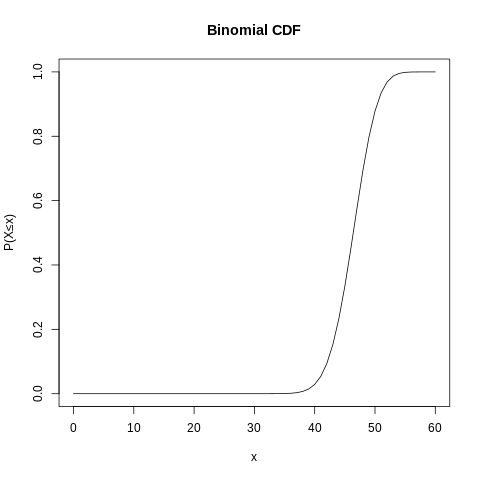

In [11]:
%%R
library(ggplot2)

n <- 60
p <- 0.78

# 1. P(X = 50)
dbinom(50, n, p)

# 2. P(X ≤ 45)
pbinom(45, n, p)

# 3. 95th percentile
qbinom(0.95, n, p)

# 4. Simulation histogram
set.seed(123)
sim_binom <- rbinom(5000, n, p)
hist(sim_binom,
     main="Binomial — 5000 Simulations",
     xlab="Immunity Count")

# 5. PMF and CDF
x <- 0:n
pmf <- dbinom(x, n, p)
cdf <- pbinom(x, n, p)

plot(x, pmf, type="h",
     main="Binomial PMF", xlab="x", ylab="P(X=x)")

plot(x, cdf, type="l",
     main="Binomial CDF", xlab="x", ylab="P(X≤x)")

**B. Poisson Analysis (Side Effects Reports)**

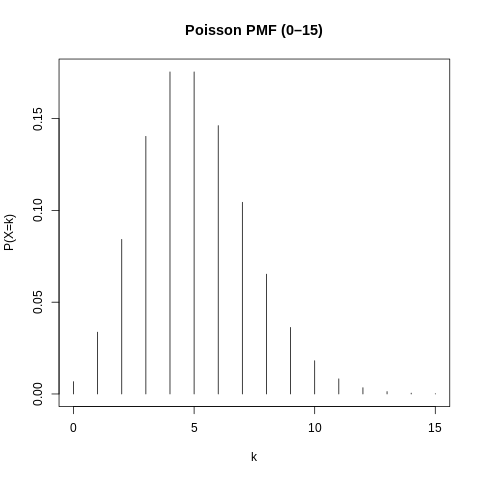

In [12]:
%%R
library(ggplot2)

lambda <- 5

# 1. P(X = 8)
dpois(8, lambda)

# 2. P(X ≤ 5)
ppois(5, lambda)

# 3. 90th percentile
qpois(0.90, lambda)

# 4. 30-day simulation
set.seed(100)
sim_pois <- rpois(30, lambda)

plot(sim_pois, type="o",
     main="Poisson — 30 Days Simulation",
     xlab="Day", ylab="Reports")

# 5. PMF 0–15
k <- 0:15
pmf_pois <- dpois(k, lambda)

plot(k, pmf_pois, type="h",
     main="Poisson PMF (0–15)",
     xlab="k", ylab="P(X=k)")

**C. Interpretation**

In [13]:
%%R
cat("Binomial Model:\n")
cat("Used to estimate how many participants develop immunity.\n")
cat("Helps evaluate vaccine effectiveness (mean = n×p).\n\n")

cat("Poisson Model:\n")
cat("Used to estimate daily side-effect reports.\n")
cat("Helps plan monitoring workload and detect unusual spikes.\n")


Binomial Model:
Used to estimate how many participants develop immunity.
Helps evaluate vaccine effectiveness (mean = n×p).

Poisson Model:
Used to estimate daily side-effect reports.
Helps plan monitoring workload and detect unusual spikes.
